<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Support%20Vector%20%20Machine%20on%20Iris%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# import the necessary libraraies
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#Load the Iris Dataset
#Load the Iris dataset.In this case we have the dataset that is pre-installed in Python
iris = load_iris()
X = iris.data #Features
y = iris.target # Target variable(species)

In [12]:
# Split the Data into Training and Testing Sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42 )

In [13]:
#Initialize and train the SVM Model
#Initialize the SVM model with radial basis function(RBF) kernel
model = SVC(kernel='rbf')

#Train the model
model.fit(X_train,y_train)


SVC()

In [14]:
# make predictions on the  test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy * 100:.2f}%")

print("\nClassificationReport:")
print(classification_report(y_test,y_pred))

Accuracy:100.00%

ClassificationReport:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



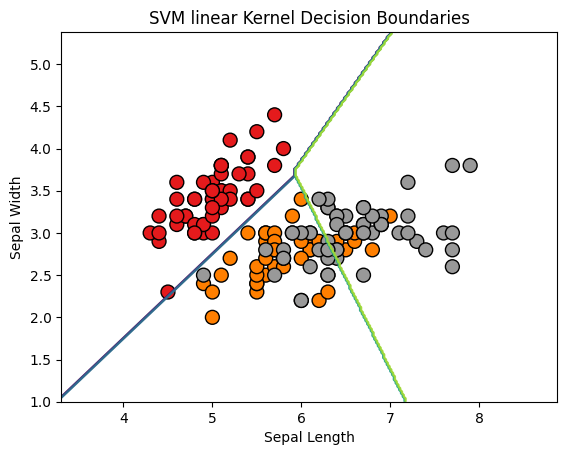

In [16]:
# Visualizing the Decision Boundary
#Extract the first two features for visualization
X_vis = X[:,:2]
X_train,X_test,y_train,y_test = train_test_split(X_vis,y,test_size=0.2,random_state=42)

#Train an SVM classifier with a linear kernel
model = SVC(kernel='linear')
model.fit(X_train,y_train)

#Plot the decision boundaries
h = .02 # Step size in the mesh
x_min, x_max = X_vis[:,0].min() - 1,X_vis[:,0].max() +1
y_min, y_max = X_vis[:,1].min() -1,X_vis[:,1].max()  +1

xx,yy = np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))

Z = model.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx,yy,Z,alpha=0.8)
plt.scatter(X_vis[:,0],X_vis[:,1],c=y,edgecolors='k',marker='o',s=100, cmap=plt.cm.Set1)
plt.title('SVM linear Kernel Decision Boundaries')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()